<a href="https://colab.research.google.com/github/dhanalakshminowgotla-hash/Customer--churn--prediction--system-/blob/main/customer_churn_prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Number of records
n = 3000

# Create dataset
data = {
    "CustomerID": ["CUST" + str(i) for i in range(1, n+1)],
    "Age": np.random.randint(18, 70, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "SubscriptionType": np.random.choice(["Basic", "Premium", "Enterprise"], n),
    "MonthlyCharges": np.random.randint(300, 5000, n),
    "TenureMonths": np.random.randint(1, 60, n),
    "SupportTickets": np.random.randint(0, 10, n),
    "PaymentMethod": np.random.choice(["Credit Card", "UPI", "Net Banking"], n),
    "SatisfactionScore": np.random.randint(1, 11, n),
    "UsageHoursPerWeek": np.random.randint(1, 50, n),
    "Churn": np.random.choice(["Yes", "No"], n)
}

df = pd.DataFrame(data)

# Show data
df.head()

,CustomerID,Age,Gender,SubscriptionType,MonthlyCharges,TenureMonths,SupportTickets,PaymentMethod,SatisfactionScore,UsageHoursPerWeek,Churn
0,CUST1,35,Female,Premium,3118,7,1,Net Banking,7,44,No
1,CUST2,64,Male,Premium,1837,55,6,Net Banking,8,10,No
2,CUST3,42,Male,Premium,3061,12,1,Credit Card,6,35,No
3,CUST4,40,Female,Premium,2626,34,1,Net Banking,5,31,Yes
4,CUST5,47,Female,Basic,4344,26,7,Net Banking,3,23,Yes


In [ ]:
df.to_csv("customer_churn_dataset.csv", index=False)

In [ ]:
df.shape   # (3000, 11) ravali
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         3000 non-null   object
 1   Age                3000 non-null   int64 
 2   Gender             3000 non-null   object
 3   SubscriptionType   3000 non-null   object
 4   MonthlyCharges     3000 non-null   int64 
 5   TenureMonths       3000 non-null   int64 
 6   SupportTickets     3000 non-null   int64 
 7   PaymentMethod      3000 non-null   object
 8   SatisfactionScore  3000 non-null   int64 
 9   UsageHoursPerWeek  3000 non-null   int64 
 10  Churn              3000 non-null   object
dtypes: int64(6), object(5)
memory usage: 257.9+ KB


,Age,MonthlyCharges,TenureMonths,SupportTickets,SatisfactionScore,UsageHoursPerWeek
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,43.018333,2609.902333,30.081667,4.483333,5.431333,24.906333
std,15.044493,1355.477172,17.214793,2.893530,2.833248,14.182287
min,18.000000,300.000000,1.000000,0.000000,1.000000,1.000000
25%,30.000000,1435.750000,15.000000,2.000000,3.000000,13.000000
50%,42.000000,2575.500000,30.000000,4.000000,5.000000,25.000000
75%,56.000000,3764.250000,45.000000,7.000000,8.000000,37.000000
max,69.000000,4999.000000,59.000000,9.000000,10.000000,49.000000


In [ ]:
n = 3000

data = pd.DataFrame({
    "customer_id": range(1, n+1),

    # Customer satisfaction (1–10)
    "satisfaction_score": np.random.randint(1, 11, n),

    # Monthly usage (hours)
    "usage_hours": np.random.randint(10, 200, n),

    # Subscription type
    "subscription_type": np.random.choice(["Basic", "Standard", "Premium"], n),

    # Support tickets
    "support_tickets": np.random.randint(0, 10, n),

    # Tenure (months)
    "tenure_months": np.random.randint(1, 60, n)
})

In [ ]:
# Churn logic
data["churn"] = (
    (data["satisfaction_score"] < 5) &
    (data["support_tickets"] > 3)
).astype(int)

In [ ]:
data.head()

,customer_id,satisfaction_score,usage_hours,subscription_type,support_tickets,tenure_months,churn
0,1,6,132,Standard,0,18,0
1,2,9,78,Basic,7,36,0
2,3,5,174,Premium,2,9,0
3,4,7,153,Standard,6,33,0
4,5,10,143,Standard,7,44,0


In [ ]:
data.to_csv("customer_churn_data.csv", index=False)

In [ ]:
data["churn"] = (
    (data["satisfaction_score"] < 5) |
    (data["tenure_months"] < 6) |
    (data["support_tickets"] > 5)
).astype(int)

In [ ]:
data.isnull().sum()

,0
customer_id,0
satisfaction_score,0
usage_hours,0
subscription_type,0
support_tickets,0
tenure_months,0
churn,0


In [ ]:
data=data.drop_duplicates()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = ["satisfaction_score", "usage_hours", "support_tickets", "tenure_months"]

data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

In [ ]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         3000 non-null   int64  
 1   satisfaction_score  3000 non-null   float64
 2   usage_hours         3000 non-null   float64
 3   subscription_type   3000 non-null   object 
 4   support_tickets     3000 non-null   float64
 5   tenure_months       3000 non-null   float64
 6   churn               3000 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 164.2+ KB


,customer_id,satisfaction_score,usage_hours,subscription_type,support_tickets,tenure_months,churn
0,1,0.194875,0.462242,Standard,-1.562156,-0.691719,0
1,2,1.225355,-0.521109,Basic,0.866605,0.362284,1
2,3,-0.148618,1.227070,Premium,-0.868224,-1.218721,0
3,4,0.538368,0.844656,Standard,0.519639,0.186617,1
4,5,1.568848,0.662554,Standard,0.866605,0.830730,1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

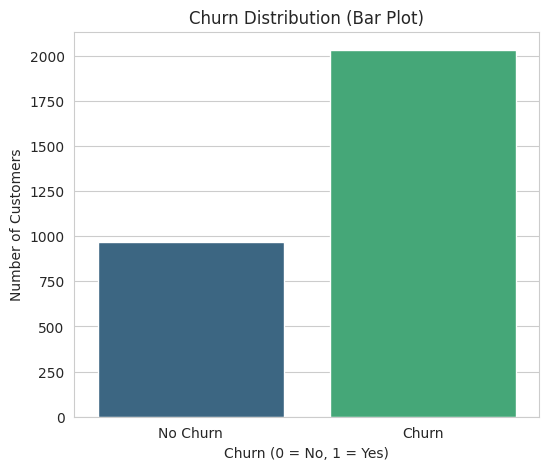

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x='churn', data=data, palette='viridis', hue='churn', legend=False)
plt.title('Churn Distribution (Bar Plot)')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


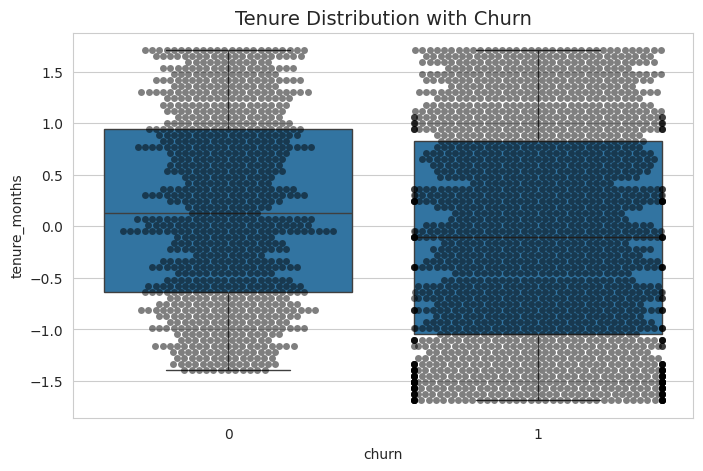

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x="churn", y="tenure_months", data=data)
sns.swarmplot(x="churn", y="tenure_months", data=data, color="black", alpha=0.5)

plt.title("Tenure Distribution with Churn", fontsize=14)
plt.show()

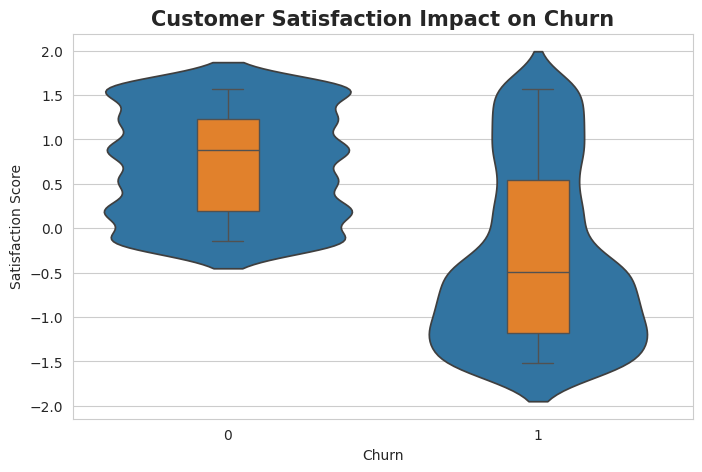

In [ ]:
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

sns.violinplot(x="churn", y="satisfaction_score", data=data, inner=None)
sns.boxplot(x="churn", y="satisfaction_score", data=data, width=0.2)

plt.title("Customer Satisfaction Impact on Churn", fontsize=15, fontweight='bold')
plt.xlabel("Churn")
plt.ylabel("Satisfaction Score")

plt.show()